**1. Install / import**

In [1]:
!pip install -q pandas scikit-learn

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

**2. Load dataset**

In [3]:
df = pd.read_csv("Housing.csv")
print("Loaded. Shape:", df.shape)

Loaded. Shape: (545, 13)


**3. Quick inspection**

In [6]:
display(df.head(8))

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished


In [7]:
print("\nInfo:")
display(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


None

In [8]:
print("\nDescribe (numeric):")
display(df.describe(include=[np.number]).round(3))


Describe (numeric):


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000,545.000,545.000,545.000,545.000
mean,4.766729e+06,5150.541,2.965,1.286,1.806,0.694
std,1.870440e+06,2170.141,0.738,0.502,0.867,0.862
min,1.750000e+06,1650.000,1.000,1.000,1.000,0.000
25%,3.430000e+06,3600.000,2.000,1.000,1.000,0.000
50%,4.340000e+06,4600.000,3.000,1.000,2.000,0.000
75%,5.740000e+06,6360.000,3.000,2.000,2.000,1.000
max,1.330000e+07,16200.000,6.000,4.000,4.000,3.000


In [9]:
print("\nUnique values per column:")
for c in df.columns:
    print(c, "->", df[c].nunique())


Unique values per column:
price -> 219
area -> 284
bedrooms -> 6
bathrooms -> 4
stories -> 4
mainroad -> 2
guestroom -> 2
basement -> 2
hotwaterheating -> 2
airconditioning -> 2
parking -> 4
prefarea -> 2
furnishingstatus -> 3


**4. Common cleaning checks**

4.1 Trim whitespace and lowercase column names for convenience

In [10]:
df.columns = [c.strip().lower() for c in df.columns]
df = df.rename(columns=lambda c: c.replace(" ", "_"))

4.2 Standardize yes/no or text booleans if present

In [11]:
bool_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for c in bool_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.lower().map({'yes':1,'no':0})
        # If some values are different, leave NaN for now
        df[c] = pd.to_numeric(df[c], errors='coerce')

**5. Missing values: overview**

In [12]:
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


5.1 Strategy: numeric -> median; categorical -> mode

In [13]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols and c != 'price']

5.2 Apply imputers (we'll create pipelines later, but first quick in-place impute for EDA)

In [14]:
# Numeric median impute
for c in num_cols:
    if df[c].isna().sum() > 0:
        median = df[c].median()
        df[c].fillna(median, inplace=True)

# Categorical mode impute
for c in cat_cols:
    if df[c].isna().sum() > 0:
        mode = df[c].mode().iloc[0]
        df[c].fillna(mode, inplace=True)

print("\nAfter simple impute, missing counts:")
print(df.isna().sum())


After simple impute, missing counts:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


**6. Convert categorical columns to appropriate types**

In [15]:
# Example: furnishingstatus might be 'furnished', 'semi-furnished', 'unfurnished'
if 'furnishingstatus' in df.columns:
    df['furnishingstatus'] = df['furnishingstatus'].astype(str).str.strip().str.lower()


**7. Outlier detection (IQR) for numeric columns - show candidates**

In [16]:
def iqr_outliers(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k*iqr
    upper = q3 + k*iqr
    return (series < lower) | (series > upper)

print("\nOutlier counts (IQR method):")
for c in num_cols:
    if c != 'price':  # show for features (but price is important too)
        out_cnt = iqr_outliers(df[c]).sum()
        print(c, "->", out_cnt)


Outlier counts (IQR method):
area -> 12
bedrooms -> 12
bathrooms -> 1
stories -> 41
mainroad -> 77
guestroom -> 97
basement -> 0
hotwaterheating -> 25
airconditioning -> 0
parking -> 12
prefarea -> 128


**8. Encode categoricals: prepare a pipeline for modeling**

In [17]:
# Decide which to one-hot and which to ordinal
onehot_cols = []
ordinal_cols = []

if 'furnishingstatus' in df.columns:
    # If furnishingstatus has a natural order: unfurnished < semi-furnished < furnished
    ordinal_cols.append('furnishingstatus')

# Add any other text columns you prefer to one-hot
for c in cat_cols:
    if c not in ordinal_cols:
        onehot_cols.append(c)

print("\nNumeric cols:", num_cols)
print("One-hot cols:", onehot_cols)
print("Ordinal cols:", ordinal_cols)


Numeric cols: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']
One-hot cols: []
Ordinal cols: ['furnishingstatus']


8.1 Define transformers

In [20]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_onehot = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

furnishing_order = ['unfurnished', 'semi-furnished', 'furnished']
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[furnishing_order], dtype=float))
])

transformer = ColumnTransformer(transformers=[
    ('num', numeric_transformer, [c for c in num_cols if c != 'price']),
    ('ord', ordinal_transformer, ordinal_cols),
    ('ohe', categorical_onehot, [c for c in onehot_cols if c not in ordinal_cols])
], remainder='drop')


**9. Split dataset into features and target, train/test split**

In [21]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("\nShapes -> train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)


Shapes -> train: (381, 12) val: (82, 12) test: (82, 12)


**10. Fit transformer on training data and transform**

In [22]:
transformer.fit(X_train)
X_train_t = transformer.transform(X_train)
X_val_t = transformer.transform(X_val)
X_test_t = transformer.transform(X_test)

print("\nTransformed shapes:", X_train_t.shape, X_val_t.shape, X_test_t.shape)



Transformed shapes: (381, 12) (82, 12) (82, 12)


**11. Save cleaned/processed datasets to disk**

In [23]:
cleaned_path = "housing_cleaned.csv"
df.to_csv(cleaned_path, index=False)
print("Saved cleaned CSV to", cleaned_path)

Saved cleaned CSV to housing_cleaned.csv


**12. Quick Inspection after cleaning**

- No missing values

In [25]:
print(df.isna().sum().sum())

0


- Dtypes look right

In [26]:
print(df.dtypes)

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad             int64
guestroom            int64
basement             int64
hotwaterheating      int64
airconditioning      int64
parking              int64
prefarea             int64
furnishingstatus    object
dtype: object


- Price distribution

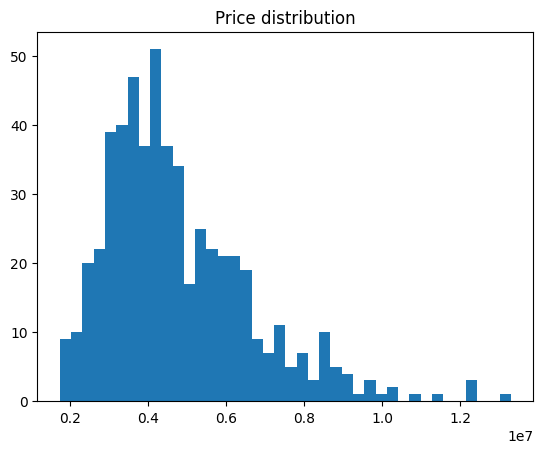

In [27]:
import matplotlib.pyplot as plt
plt.hist(df['price'], bins=40)
plt.title("Price distribution")
plt.show()